# Question 1 — Which brain area has the highest ripple density?

## Final answer: Brain area 1

This notebook is the shareable analysis record for Question 1. It performs
only lightweight loading and verification; expensive spectral calculations,
event detection, and ML inference are **not recomputed**.

### Notebook roadmap

1. Verify the structure and duration of the provided LFP recordings.
2. Display saved signal, spectrum, filter, and event-quality checks.
3. Explain the final robust-RMS ripple-candidate detector.
4. Load the saved 17-mouse summaries and paired statistical tests.
5. Present the main result plot with mouse trajectories, group means, and
   95% mouse-bootstrap confidence intervals.
6. Document rejected pretrained-model sensitivity checks and state the answer.


## Analysis scope

- Ripple density: accepted 100–200 Hz ripple candidates per minute.
- Mouse/session is the independent observation.
- Mouse 12 is excluded by the chosen cohort definition.
- Final sample: 17 mice.
- Three evenly spaced channels are analysed per brain area and summarized by
  their median rate within each mouse.


In [9]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "code-snippets":
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"
FINAL_ASSETS = RESULTS_DIR / "q1_final"
FS = 500.0


## Load and verify the LFP data

The following cell memory-maps Mouse 1 rather than loading the complete arrays
into RAM. It is a lightweight data-structure check, not a recalculation.


In [10]:
mouse_id = 1
lfps = {
    area: np.load(DATA_DIR / str(mouse_id) / f"lfp_{area}.npy", mmap_mode="r")
    for area in (1, 2, 3)
}

lfp_summary = pd.DataFrame([
    {
        "brain_area": area,
        "channels": lfp.shape[0],
        "samples": lfp.shape[1],
        "duration_min": lfp.shape[1] / FS / 60,
        "dtype": str(lfp.dtype),
    }
    for area, lfp in lfps.items()
])
lfp_summary


,brain_area,channels,samples,duration_min,dtype
0,1,28,1675486,55.849533,float64
1,2,25,1675486,55.849533,float64
2,3,47,1675486,55.849533,float64


## Signal inspection and band selection

These figures were generated during the Mouse 1 exploratory analysis and are
loaded from disk here. The 100–200 Hz band was chosen because the recordings
are sampled at 500 Hz (Nyquist = 250 Hz), while retaining possible lower
frequency ripple energy.


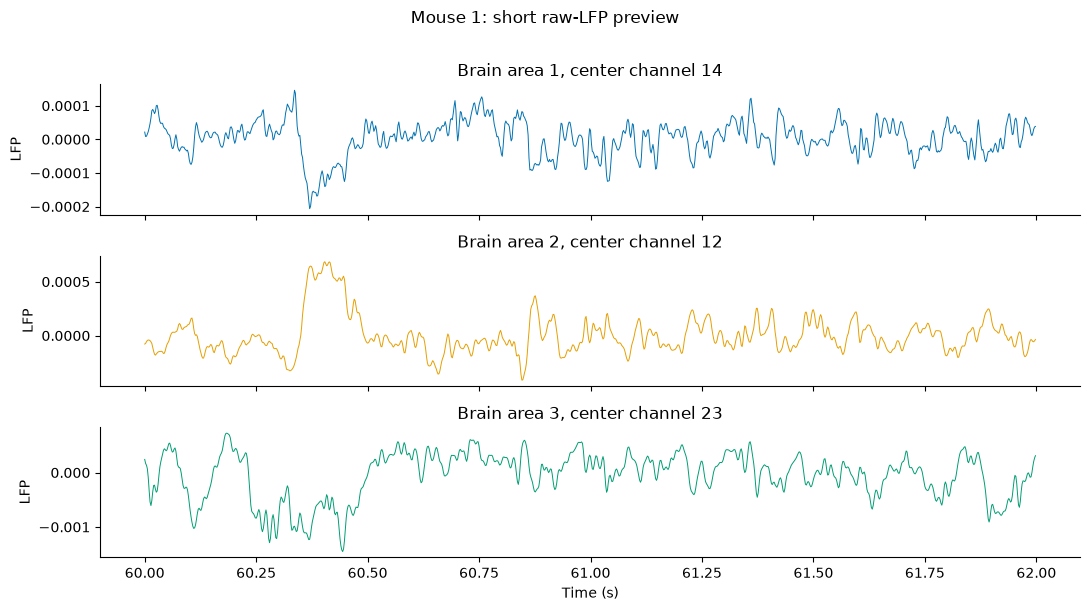

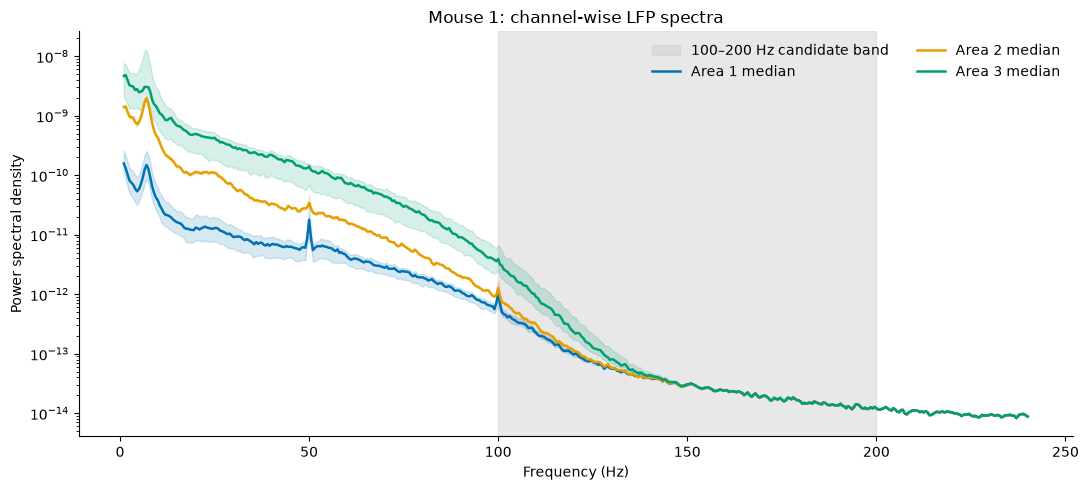

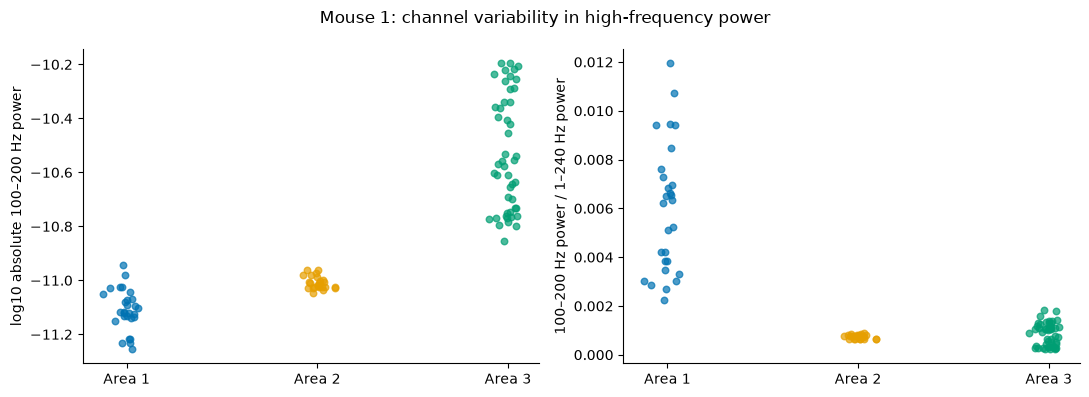

In [11]:
display(Image(filename=str(FINAL_ASSETS / "mouse1_raw_lfp.png")))
display(Image(filename=str(FINAL_ASSETS / "mouse1_spectra.png")))
display(Image(filename=str(FINAL_ASSETS / "mouse1_channel_power.png")))


### Filter and morphology check

The filter response and one-second filtered preview were saved from the
exploratory notebook. The filtered trace was used only for visual validation.


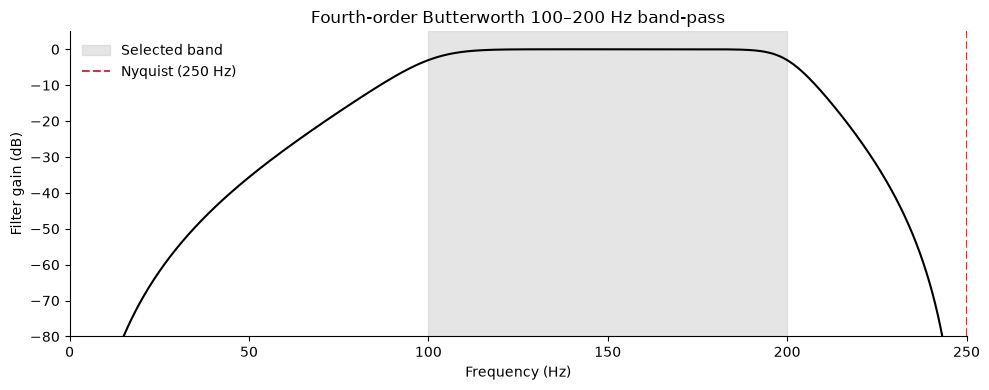

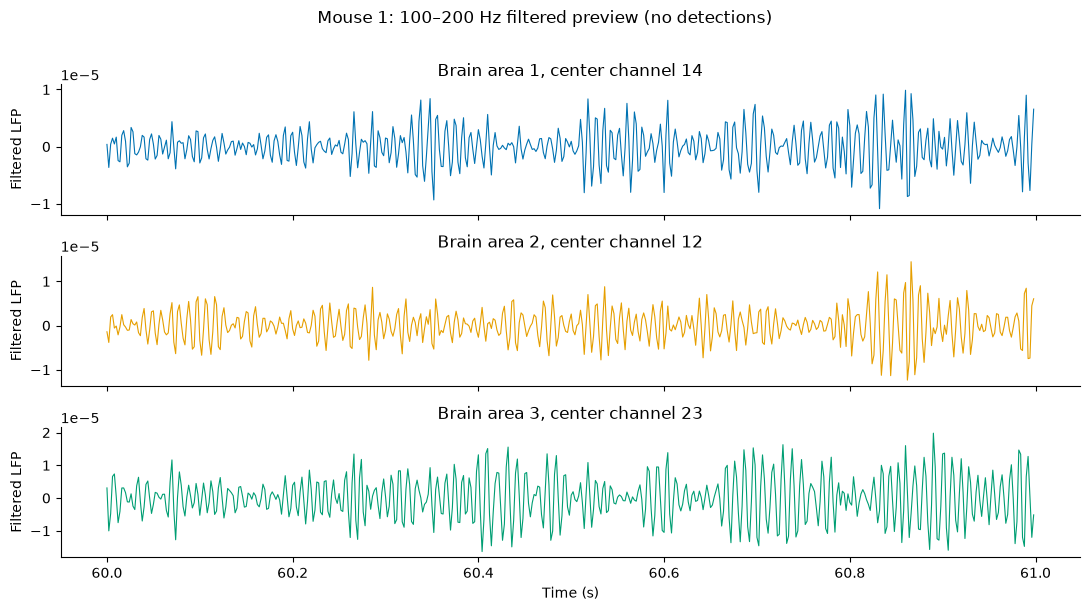

In [ ]:
display(Image(filename=str(FINAL_ASSETS / "filter_response.png")))
display(Image(filename=str(FINAL_ASSETS / "mouse1_filtered_preview.png")))

## Final robust RMS detector

For every selected channel:

1. Zero-phase fourth-order Butterworth filtering at 100–200 Hz.
2. A 20 ms moving RMS envelope.
3. Channel-specific robust normalization using median and MAD.
4. Event initiation above 4 robust SD; boundaries extended to 2 robust SD.
5. Accepted duration: 20–200 ms.
6. Reject candidates overlapping raw amplitudes above 20 robust SD.
7. Divide accepted event count by valid recording duration in minutes.

The median of three channel rates gives one value per mouse and brain area.


## Load the saved 17-mouse results

The CSV and JSON files below were produced by `run_q1_rms.py`.


In [13]:
rms_summary = pd.read_csv(RESULTS_DIR / "q1_rms" / "summary.csv")
rms_mouse_results = pd.read_csv(
    RESULTS_DIR / "q1_rms" / "mouse_results.csv"
)
with open(RESULTS_DIR / "q1_rms" / "tests.json", encoding="utf-8") as file:
    rms_tests = json.load(file)

display(rms_summary)
display(pd.DataFrame(rms_tests["pairwise"]))


,brain_area,mean_events_per_min,ci95_low,ci95_high,median_events_per_min,n_mice
0,1,56.202139,44.365388,70.077172,46.140852,17
1,2,48.932732,37.452493,62.546840,39.427154,17
2,3,37.116332,29.919318,47.108521,31.777980,17


,left_area,right_area,mean_paired_difference,p_raw,left_wins,right_wins,p_holm
0,1,2,7.269407,0.001343,15,2,0.002686
1,1,3,19.085807,0.000076,15,2,0.000229
2,2,3,11.816400,0.002090,14,3,0.002686


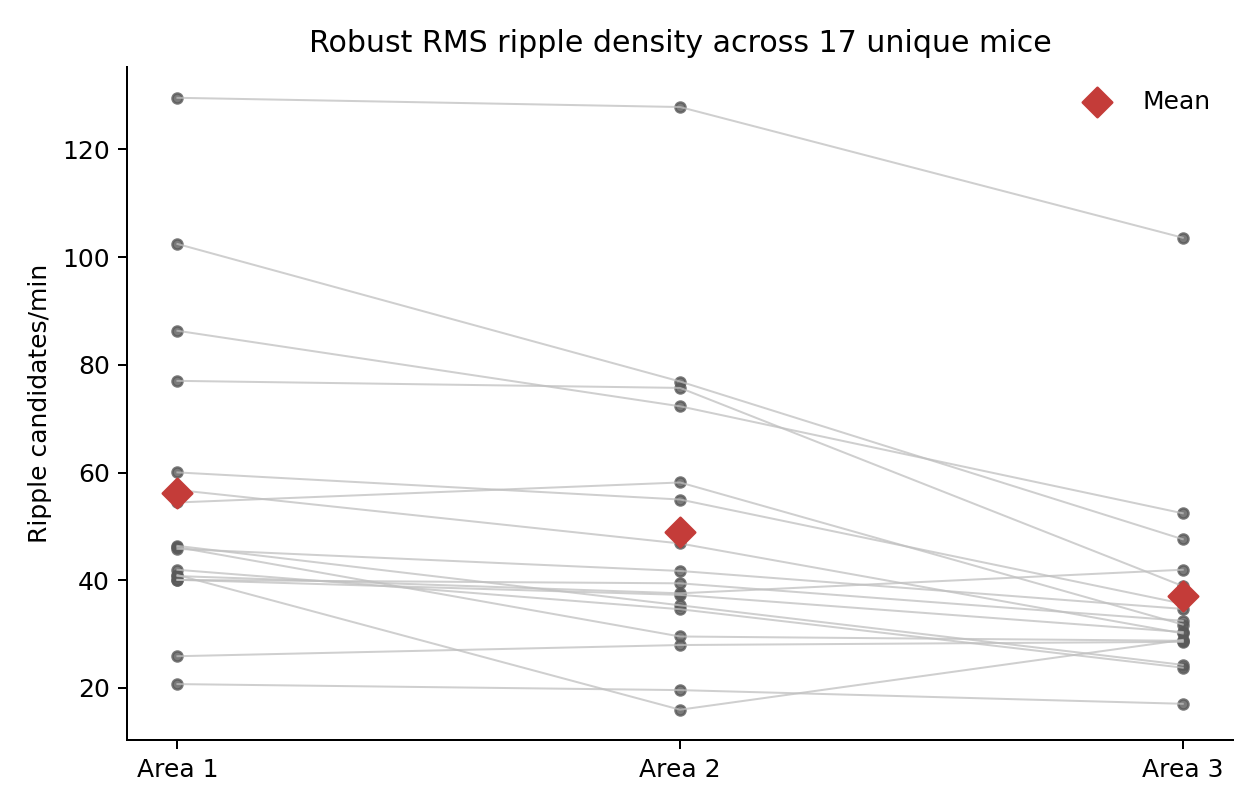

In [14]:
display(Image(filename=str(
    RESULTS_DIR / "q1_rms" / "paired_mouse_rates.png"
)))


## Quantitative result

| Brain area | Mean ripple density | 95% bootstrap CI |
|---|---:|---:|
| Area 1 | **56.20 events/min** | **44.37–70.08** |
| Area 2 | 48.93 events/min | 37.45–62.55 |
| Area 3 | 37.12 events/min | 29.92–47.11 |

The paired Friedman test found an overall difference
($p=9.75\times10^{-5}$). Area 1 exceeded both Area 2 and Area 3 in 15 of 17
mice. Holm-adjusted paired Wilcoxon results were:

- Area 1 versus Area 2: $p=0.00269$.
- Area 1 versus Area 3: $p=0.000229$.

The confidence intervals were calculated with 20,000 mouse-level bootstrap
resamples.


## Mouse 1 event-level visual check

Blue bars are robust RMS detections. The magenta supervised event-quality
classifier was an exploratory external-data check and was rejected because it
produced approximately three times as many events, had low temporal overlap,
and reversed the area ranking. The separate marker rows ensure coincident
detections remain visible.


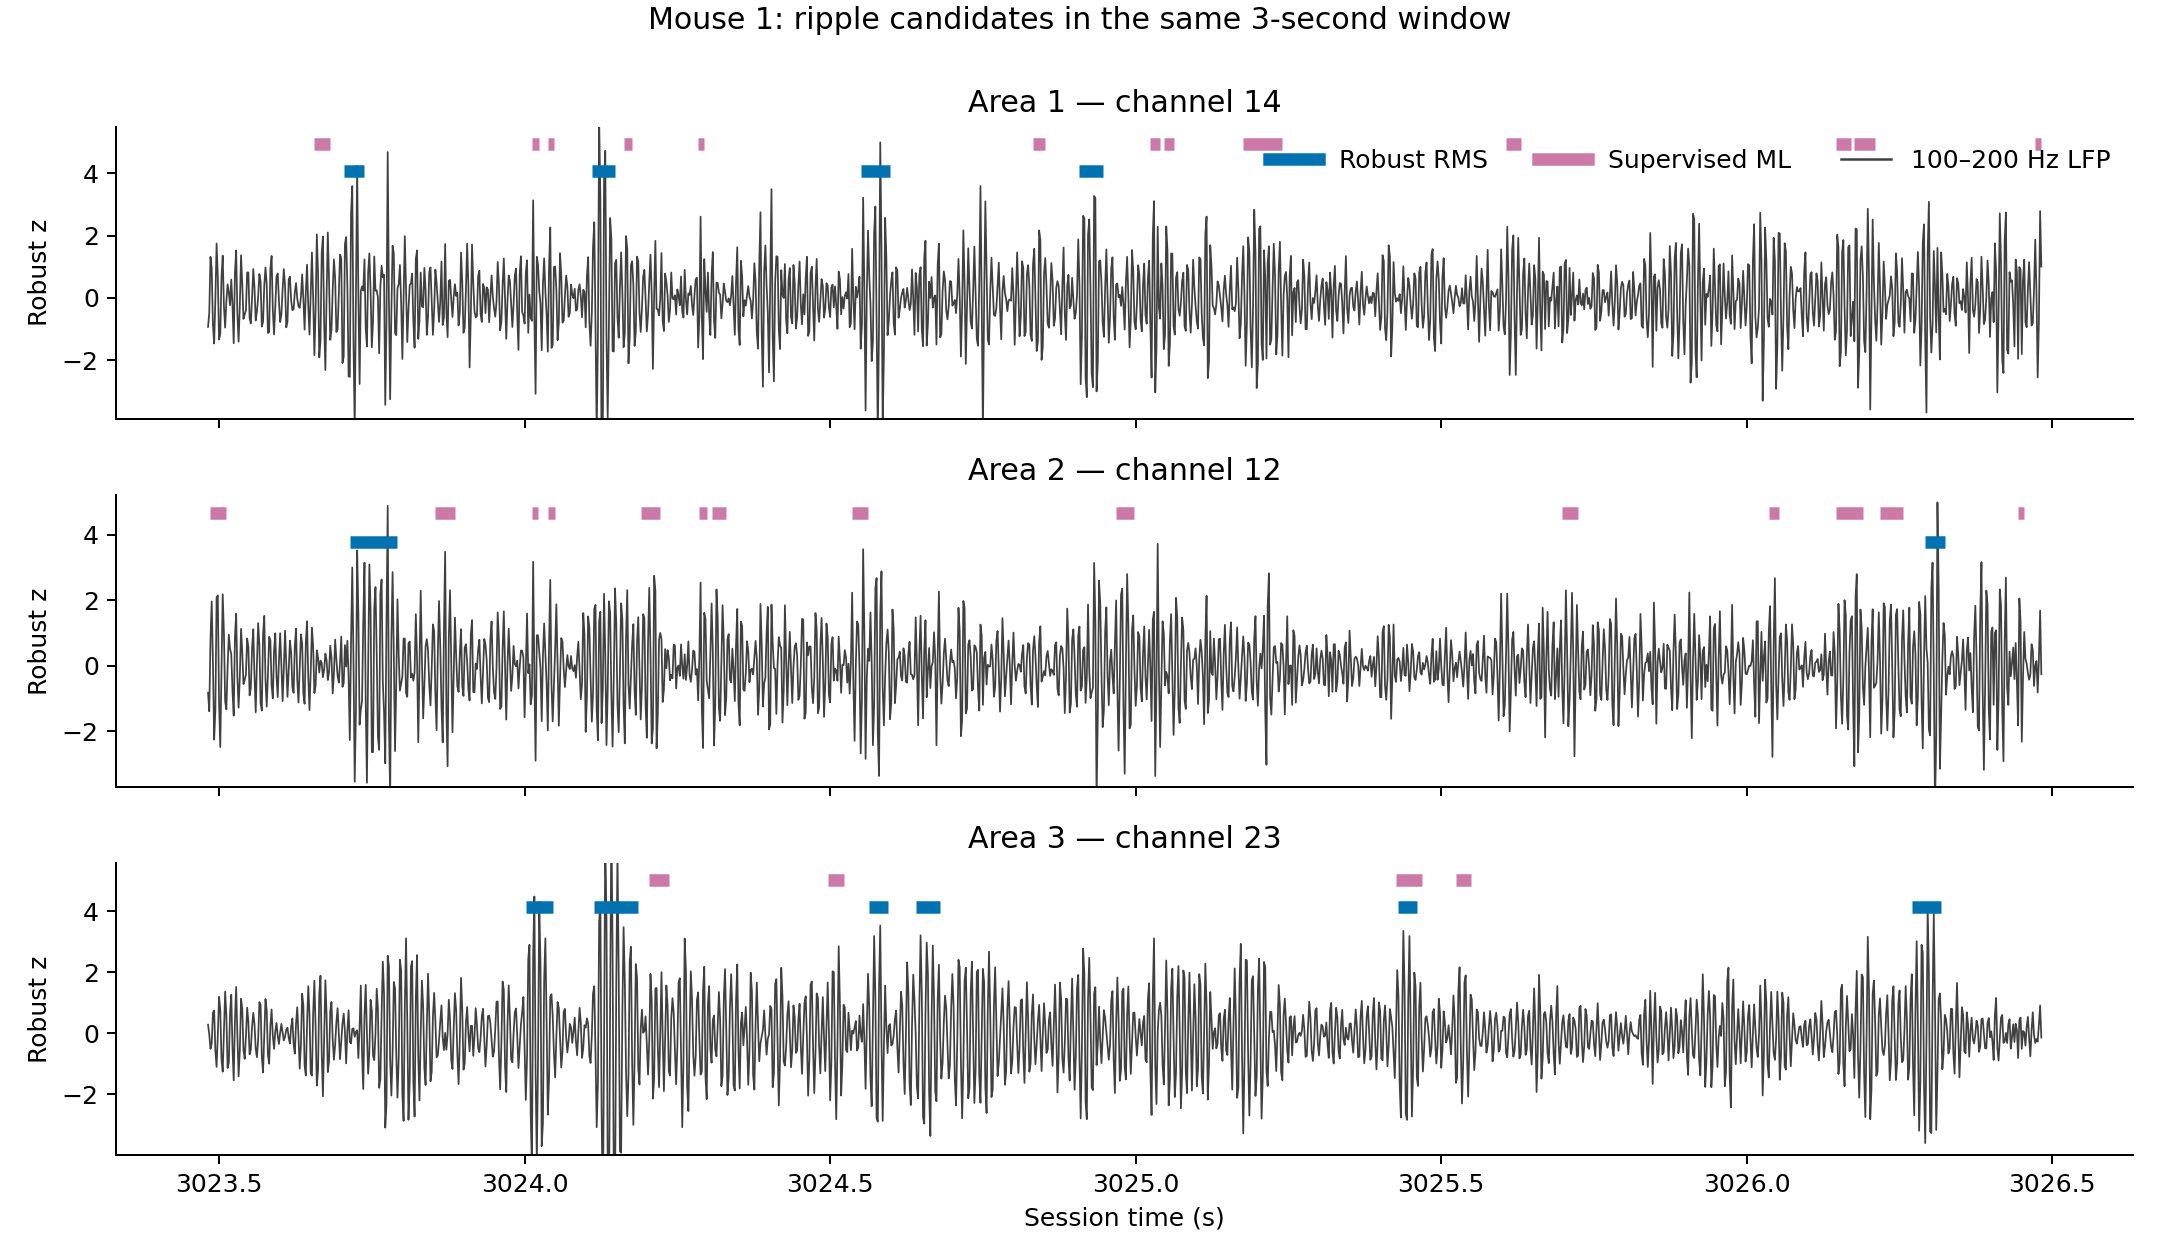

In [15]:
display(Image(filename=str(
    RESULTS_DIR / "q1_supervised" / "mouse_1_ripple_example.png"
)))


## Pretrained rippl-AI sensitivity check

PridaLab's pretrained CNN1D was also tested on Mouse 1 after polyphase
resampling from 500 to 1,250 Hz.

At its documented probability threshold of 0.5, the eight-channel model
produced 0.20, 0.04, and 0.25 events/min in Areas 1–3, compared with RMS rates
of 25.89, 27.97, and 28.56 events/min. It matched below 0.4% of same-channel
RMS events. Lowering the threshold to 0.1 did not resolve the mismatch and
ranked Area 3 highest. The single-channel fallback detected zero or one event
per area.

This was treated as failed transfer caused by sampling, recording, and
anatomical-domain mismatch—not as evidence against the RMS result.


,mouse,brain_area,pyramidal_channel,cnn_channels,duration_min,cnn_native_events,cnn_duration_filtered_events,cnn_events_per_min,cnn_median_duration_ms,same_channel_rms_events_per_min,final_rms_area_events_per_min,fraction_rms_matched_by_cnn,fraction_cnn_matched_by_rms,probability_p99,probability_p999,probability_max,elapsed_seconds
0,1,1,27,27 25 23 21 19 17 15 13,55.849533,118,11,0.196958,25.6,25.890995,25.890995,0.000692,0.090909,0.122942,0.398708,0.999941,22.770763
1,1,2,11,17 15 13 11 9 7 5 3,55.849533,4,2,0.035811,32.0,26.839974,27.968005,0.001334,1.000000,0.011548,0.054654,0.999999,22.770763
2,1,3,18,24 22 20 18 16 14 12 10,55.849533,321,14,0.250674,25.6,26.625111,28.558878,0.003362,0.357143,0.199071,0.530494,0.994352,22.770763


brain_area,1,2,3
threshold,,,
0.1,5.425292,0.250674,15.846149
0.2,1.128031,0.071621,4.136113
0.3,0.501347,0.035811,1.718904
0.4,0.232768,0.035811,0.680400
0.5,0.196958,0.035811,0.250674


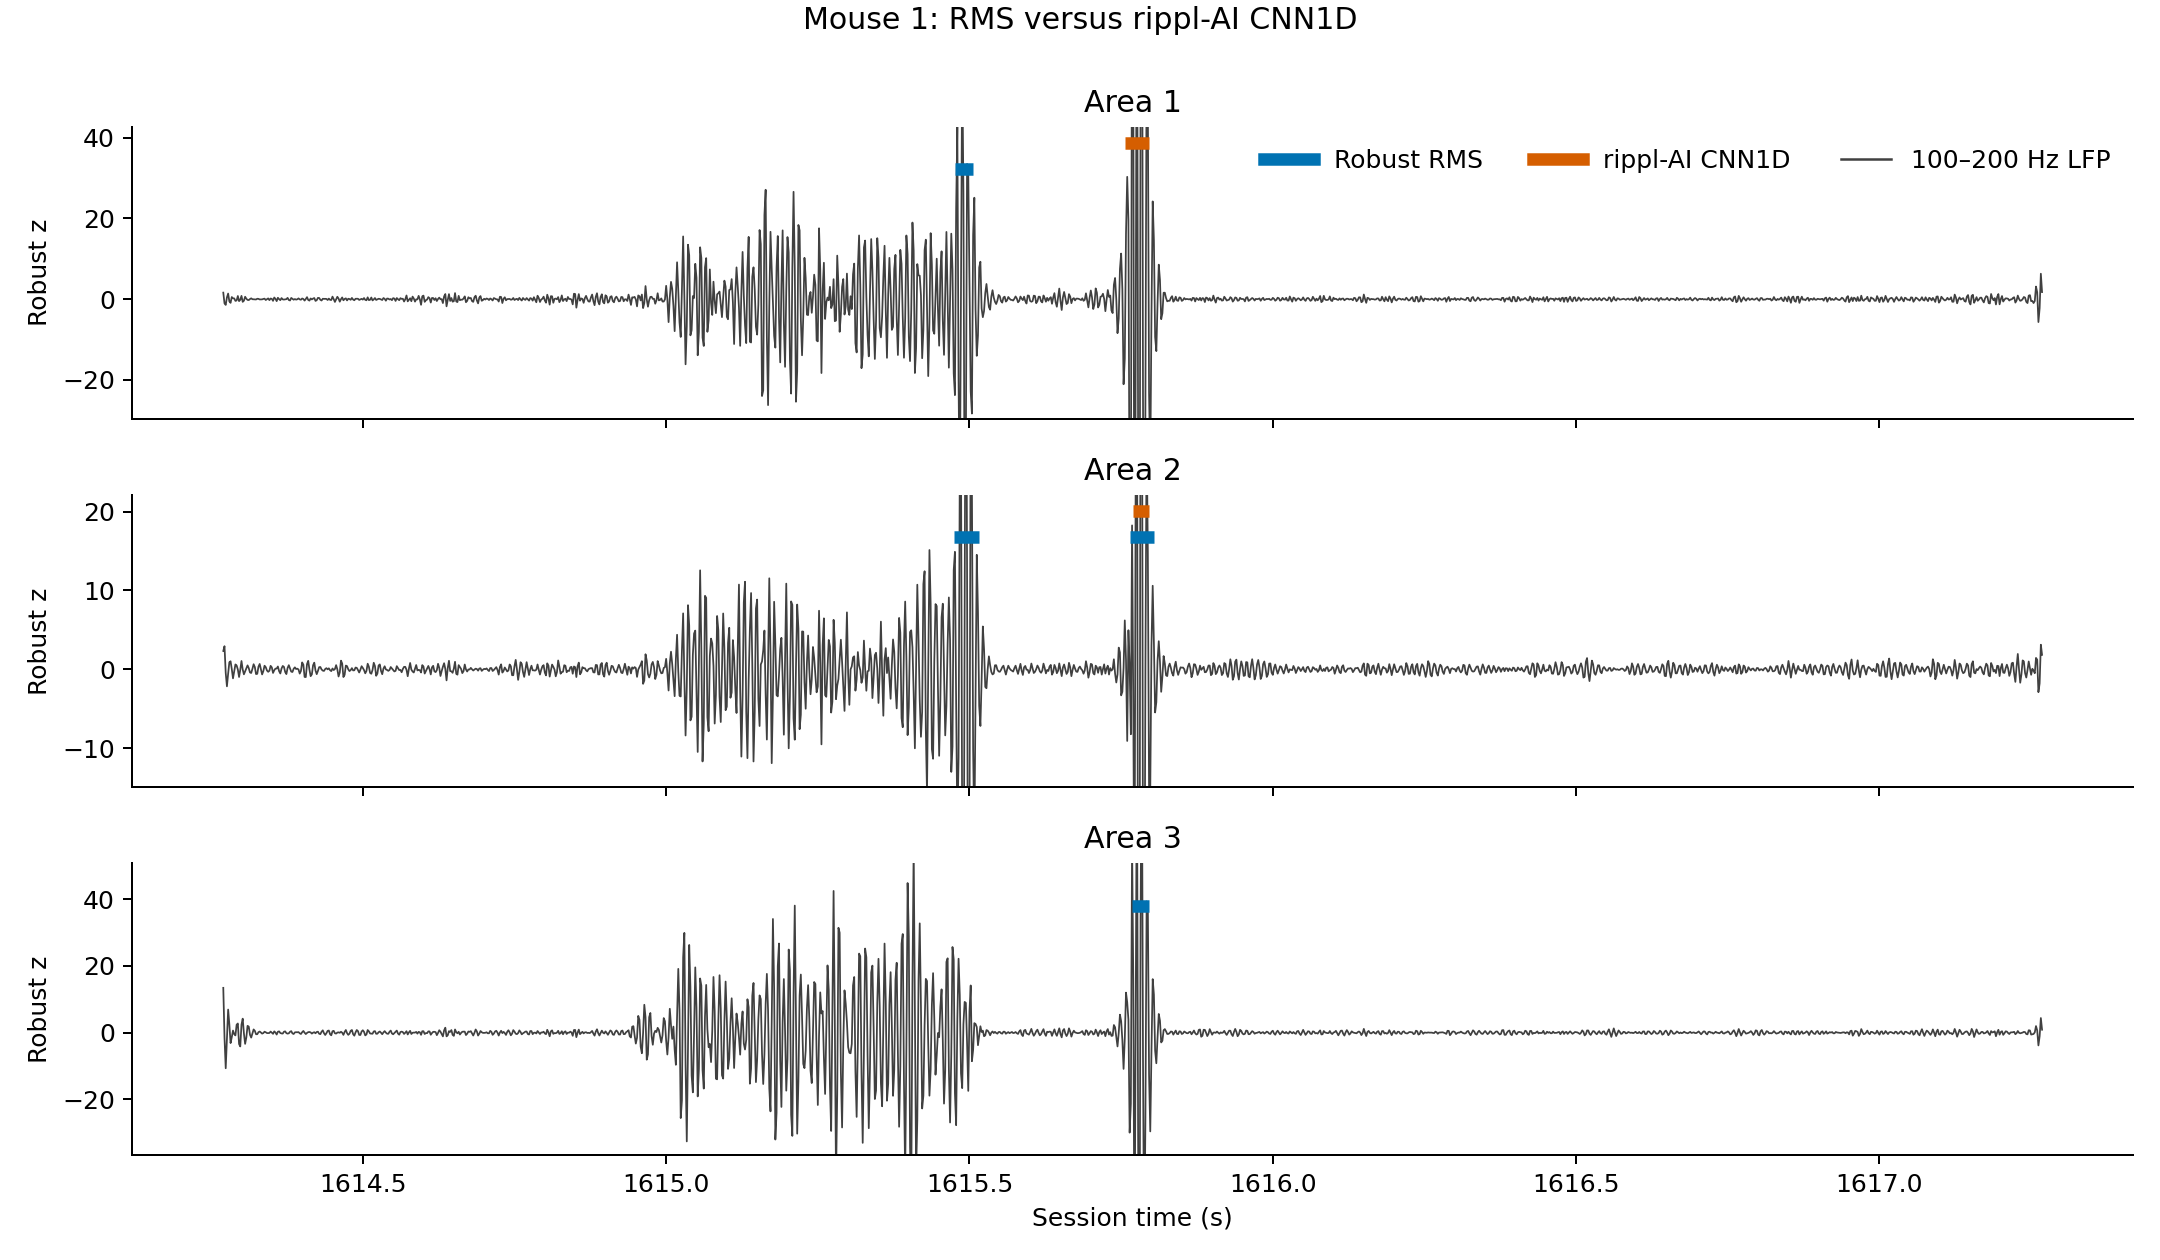

In [16]:
rippl_ai_comparison = pd.read_csv(
    RESULTS_DIR / "q1_rippl_ai" / "mouse_1_comparison.csv"
)
rippl_ai_thresholds = pd.read_csv(
    RESULTS_DIR / "q1_rippl_ai" / "mouse_1_threshold_sensitivity.csv"
)
display(rippl_ai_comparison)
display(rippl_ai_thresholds.pivot(
    index="threshold",
    columns="brain_area",
    values="events_per_min",
))
display(Image(filename=str(
    RESULTS_DIR / "q1_rippl_ai" / "mouse_1_rms_vs_rippl_ai.png"
)))


# Final answer: Brain area 1

Area 1 had the highest mean ripple-candidate density, won the paired comparison
in 15 of 17 mice against each alternative, and differed significantly from
both Areas 2 and 3 after multiplicity correction.

These are automatically detected **ripple candidates**, not manually curated
sharp-wave ripples; nevertheless, the paired mouse-level evidence is
sufficient to select **Brain area 1** for the multiple-choice question.
